## Load the raw data

We begin by importing the libraries and reading the Olympic and GDP files. The reason is to inspect the raw structure first, so we know what columns exist and what years are available before cleaning anything.


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../src")
from utils import code_fix

import numpy as np



olympic_path = "../data/olympic_medals.csv"
gdp_path =  "../data/gdp_absolute/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_94769.csv"

olympic_raw = pd.read_csv(olympic_path)
gdp_raw = pd.read_csv(gdp_path, skiprows=4)

display(olympic_raw.head())
display(gdp_raw.iloc[:5, :10])

print(f"Olympic rows: {len(olympic_raw):,}")
print(f"Olympic year range: {olympic_raw['year'].min()}-{olympic_raw['year'].max()}")
print(f"GDP year columns: {gdp_raw.columns[4]}-{gdp_raw.columns[-2]}")

,season,year,medal,country_code,country,games,sport,event_gender,event_name
0,Summer,1896,Gold,USA,United States,1896 Athens,Athletics,Men's,100m
1,Summer,1896,Silver,GER,Germany,1896 Athens,Athletics,Men's,100m
2,Summer,1896,Bronze,HUN,Hungary,1896 Athens,Athletics,Men's,100m
3,Summer,1896,Bronze,USA,United States,1896 Athens,Athletics,Men's,100m
4,Summer,1896,Gold,USA,United States,1896 Athens,Athletics,Men's,400m


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN


Olympic rows: 21,261
Olympic year range: 1896-2024
GDP year columns: 1960-2025


## Prepare the Olympic data

The Olympic file is too detailed for our merge because it is at medal-event level. We aggregate it to country, year, and season, and we standardize the country codes with `utils.code_fix` so they can match the World Bank GDP data.


In [2]:
# Olympic data is event-level, so aggregate medals to country-year-season first.
olympic_country_year = (
    olympic_raw.assign(
        country_code_wb=lambda df: df["country_code"].str.upper().str.strip().replace(code_fix)
    )
    .groupby(["country", "country_code_wb", "year", "season"], as_index=False)
    .size()
    .rename(columns={"size": "medal_count"})
)

# The GDP files start in 1960, so that is the maximum shared period.
olympic_country_year = olympic_country_year.loc[olympic_country_year["year"] >= 1960].copy()

olympic_country_year.head()

,country,country_code_wb,year,season,medal_count
0,AIN,AIN,2024,Summer,5
1,Afghanistan,AFG,2008,Summer,1
2,Afghanistan,AFG,2012,Summer,1
3,Albania,ALB,2024,Summer,2
4,Algeria,DZA,1984,Summer,2


## Reshape the GDP current USD data

The GDP file is wide, with one column per year, which is not convenient for a merge. We reshape it into a long table and interpolate missing values, because we want one row per country-year and better coverage across time.


In [3]:
year_columns = [col for col in gdp_raw.columns if str(col).isdigit()]

gdp_long = (
    gdp_raw.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_columns,
        var_name="year",
        value_name="gdp_current_usd",
    )
    .assign(
        year=lambda df: df["year"].astype(int),
        gdp_current_usd=lambda df: pd.to_numeric(df["gdp_current_usd"], errors="coerce"),
    )
    [["Country Name", "Country Code", "year", "gdp_current_usd"]]
    .sort_values(["Country Name", "year"])
)

# Fill gaps within each country series to maximize coverage.
gdp_long["gdp_current_usd_filled"] = (
    gdp_long.groupby("Country Name")["gdp_current_usd"]
    .transform(lambda values: values.interpolate(limit_direction="both"))
)

gdp_long.head(20)

,Country Name,Country Code,year,gdp_current_usd,gdp_current_usd_filled
2,Afghanistan,AFG,1960,NaN,3.521418e+09
268,Afghanistan,AFG,1961,NaN,3.521418e+09
534,Afghanistan,AFG,1962,NaN,3.521418e+09
800,Afghanistan,AFG,1963,NaN,3.521418e+09
1066,Afghanistan,AFG,1964,NaN,3.521418e+09
1332,Afghanistan,AFG,1965,NaN,3.521418e+09
1598,Afghanistan,AFG,1966,NaN,3.521418e+09
1864,Afghanistan,AFG,1967,NaN,3.521418e+09
2130,Afghanistan,AFG,1968,NaN,3.521418e+09
2396,Afghanistan,AFG,1969,NaN,3.521418e+09


## Merge Olympic medals with GDP current USD

Now we join the cleaned Olympic table with the reshaped GDP table using country code and year. The goal is to create one consistent dataset where medal counts and GDP values are aligned for the same country and year.


In [4]:
merged_olympics_gdp = (
    olympic_country_year.merge(
        gdp_long,
        left_on=["country_code_wb", "year"],
        right_on=["Country Code", "year"],
        how="left",
    )
    .dropna(subset=["gdp_current_usd_filled"])
    .rename(columns={"Country Name": "country_wb", "Country Code": "gdp_country_code"})
    [[
        "country",
        "country_wb",
        "gdp_country_code",
        "year",
        "season",
        "medal_count",
        "gdp_current_usd_filled",
    ]]
    .rename(columns={"gdp_current_usd_filled": "gdp_current_usd"})
    .sort_values(["year", "season", "country"])
    .reset_index(drop=True)
)

assert merged_olympics_gdp.isna().sum().sum() == 0, "The merged dataset still has missing values."

excluded_countries = sorted(
    set(olympic_country_year["country"]) - set(merged_olympics_gdp["country"])
)

print(f"Merged rows: {len(merged_olympics_gdp):,}")
print(f"Countries retained: {merged_olympics_gdp['country'].nunique()}")
print(f"Year range retained: {merged_olympics_gdp['year'].min()}-{merged_olympics_gdp['year'].max()}")
print(f"Total missing values: {merged_olympics_gdp.isna().sum().sum()}")
print("Dropped entities with no reliable GDP match:")
print(excluded_countries)

output_path = "../data/olympics_gdp_current_usd_merged.csv"
merged_olympics_gdp.to_csv(output_path, index=False)
print(f"Saved merged dataset to: {output_path}")

merged_olympics_gdp.head(20)

Merged rows: 1,420
Countries retained: 158
Year range retained: 1960-2024
Total missing values: 0
Dropped entities with no reliable GDP match:
['AIN', 'British West Indies', 'Chinese Taipei', 'Independent Olympic Athletes', 'Independent Participants (ex Yugoslavia)', 'Korea DPR', 'Refugee Olympic Team', 'Republic of China (Taiwan)']
Saved merged dataset to: ../data/olympics_gdp_current_usd_merged.csv


,country,country_wb,gdp_country_code,year,season,medal_count,gdp_current_usd
0,Argentina,Argentina,ARG,1960,Summer,2,1.586547e+10
1,Australia,Australia,AUS,1960,Summer,22,1.863568e+10
2,Austria,Austria,AUT,1960,Summer,2,6.624086e+09
3,Belgium,Belgium,BEL,1960,Summer,4,1.181062e+10
4,Brazil,Brazil,BRA,1960,Summer,2,1.703047e+10
5,Bulgaria,Bulgaria,BGR,1960,Summer,7,1.983923e+10
6,Canada,Canada,CAN,1960,Summer,1,4.056377e+10
7,Czechoslovakia,Czechia,CZE,1960,Summer,8,4.101688e+10
8,Denmark,Denmark,DNK,1960,Summer,6,6.361167e+09
9,Ethiopia,Ethiopia,ETH,1960,Summer,1,1.610512e+09


## Build the GDP per capita version

We repeat the same logic for GDP per capita so the preprocessing stays consistent. This gives us a second merged dataset that reflects wealth per person rather than total economic size.


In [5]:
gdp_per_capita_raw = pd.read_csv(
    "../data/gdp_per_capita/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv",
    skiprows=4,
    encoding="utf-8-sig",
)

gdp_per_capita_year_columns = [col for col in gdp_per_capita_raw.columns if str(col).isdigit()]

gdp_per_capita_long = (
    gdp_per_capita_raw.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=gdp_per_capita_year_columns,
        var_name="year",
        value_name="gdp_per_capita",
    )
    .assign(
        year=lambda df: df["year"].astype(int),
        gdp_per_capita=lambda df: pd.to_numeric(df["gdp_per_capita"], errors="coerce"),
    )
    [["Country Name", "Country Code", "year", "gdp_per_capita"]]
    .sort_values(["Country Name", "year"])
)

gdp_per_capita_long["gdp_per_capita_filled"] = (
    gdp_per_capita_long.groupby("Country Name")["gdp_per_capita"]
    .transform(lambda values: values.interpolate(limit_direction="both"))
)

merged_olympics_gdp_per_capita = (
    olympic_country_year.merge(
        gdp_per_capita_long,
        left_on=["country_code_wb", "year"],
        right_on=["Country Code", "year"],
        how="left",
    )
    .dropna(subset=["gdp_per_capita_filled"])
    .rename(columns={"Country Name": "country_wb", "Country Code": "gdp_country_code"})
    [[
        "country",
        "country_wb",
        "gdp_country_code",
        "year",
        "season",
        "medal_count",
        "gdp_per_capita_filled",
    ]]
    .rename(columns={"gdp_per_capita_filled": "gdp_per_capita"})
    .sort_values(["year", "season", "country"])
    .reset_index(drop=True)
)

assert (
    merged_olympics_gdp_per_capita.isna().sum().sum() == 0
), "The GDP per capita merged dataset still has missing values."

gdp_per_capita_output_path = "../data/olympics_gdp_merged.csv"
merged_olympics_gdp_per_capita.to_csv(gdp_per_capita_output_path, index=False)
print(f"Saved merged GDP per capita dataset to: {gdp_per_capita_output_path}")

merged_olympics_gdp_per_capita.head(20)


Saved merged GDP per capita dataset to: ../data/olympics_gdp_merged.csv


,country,country_wb,gdp_country_code,year,season,medal_count,gdp_per_capita
0,Argentina,Argentina,ARG,1960,Summer,2,778.251707
1,Australia,Australia,AUS,1960,Summer,22,1813.431099
2,Austria,Austria,AUT,1960,Summer,2,939.914815
3,Belgium,Belgium,BEL,1960,Summer,4,1290.286072
4,Brazil,Brazil,BRA,1960,Summer,2,235.266010
5,Bulgaria,Bulgaria,BGR,1960,Summer,7,2238.802958
6,Canada,Canada,CAN,1960,Summer,1,2264.948497
7,Czechoslovakia,Czechia,CZE,1960,Summer,8,3969.367335
8,Denmark,Denmark,DNK,1960,Summer,6,1389.021394
9,Ethiopia,Ethiopia,ETH,1960,Summer,1,75.339609


## Visualize GDP and medal counts

This first plot focuses on the latest available year and compares total GDP with total medals. The simple idea is to see whether countries with larger economies also tend to win more medals.


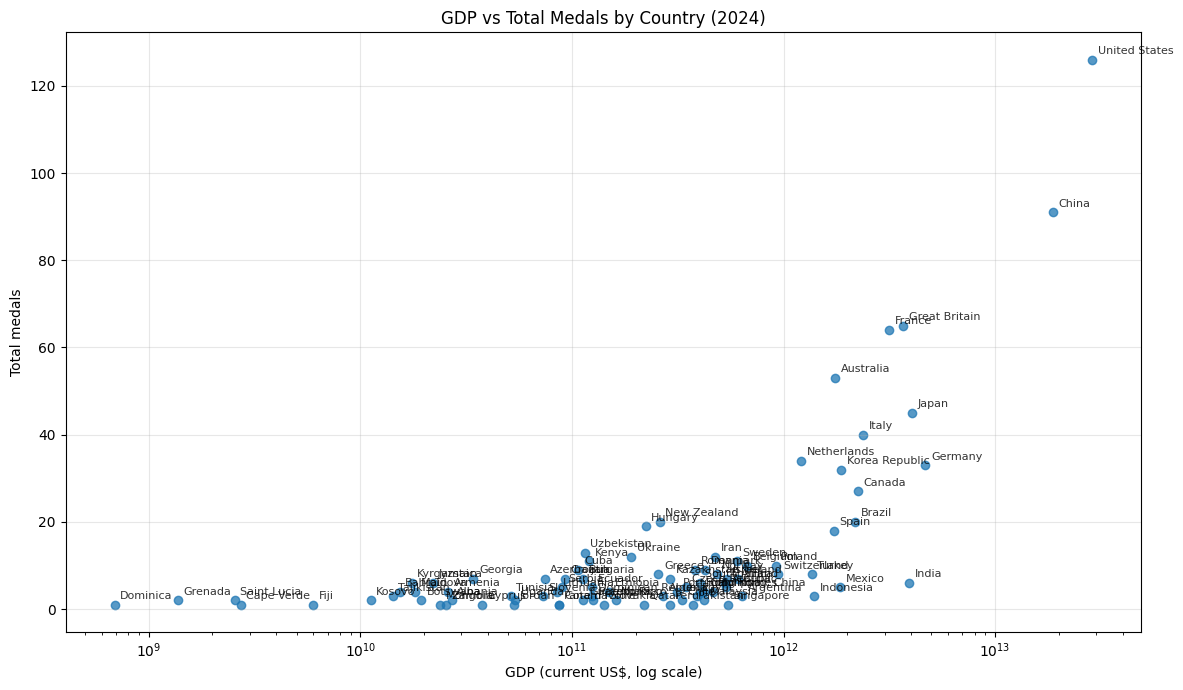

,country,gdp_current_usd,total_medals
85,United States,2.875096e+13,126
15,China,1.874380e+13,91
32,Great Britain,3.686033e+12,65
29,France,3.160443e+12,64
4,Australia,1.757022e+12,53
45,Japan,4.027598e+12,45
43,Italy,2.380825e+12,40
58,Netherlands,1.214928e+12,34
31,Germany,4.685593e+12,33
49,Korea Republic,1.875388e+12,32


In [6]:
latest_year = merged_olympics_gdp["year"].max()

scatter_df = (
    merged_olympics_gdp.loc[merged_olympics_gdp["year"] == latest_year]
    .groupby(["country", "gdp_current_usd"], as_index=False)["medal_count"]
    .sum()
    .rename(columns={"medal_count": "total_medals"})
)

plt.figure(figsize=(12, 7))
plt.scatter(scatter_df["gdp_current_usd"], scatter_df["total_medals"], alpha=0.75)

for _, row in scatter_df.iterrows():
    plt.annotate(
        row["country"],
        (row["gdp_current_usd"], row["total_medals"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=0.8,
    )

plt.xscale("log")
plt.xlabel("GDP (current US$, log scale)")
plt.ylabel("Total medals")
plt.title(f"GDP vs Total Medals by Country ({latest_year})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

scatter_df.sort_values("total_medals", ascending=False).head(10)

## Add GDP per capita to the same comparison

This bubble chart keeps GDP and medals on the axes, but it uses GDP per capita as the bubble size. The reason is to show total economic size and average wealth per person in one figure.


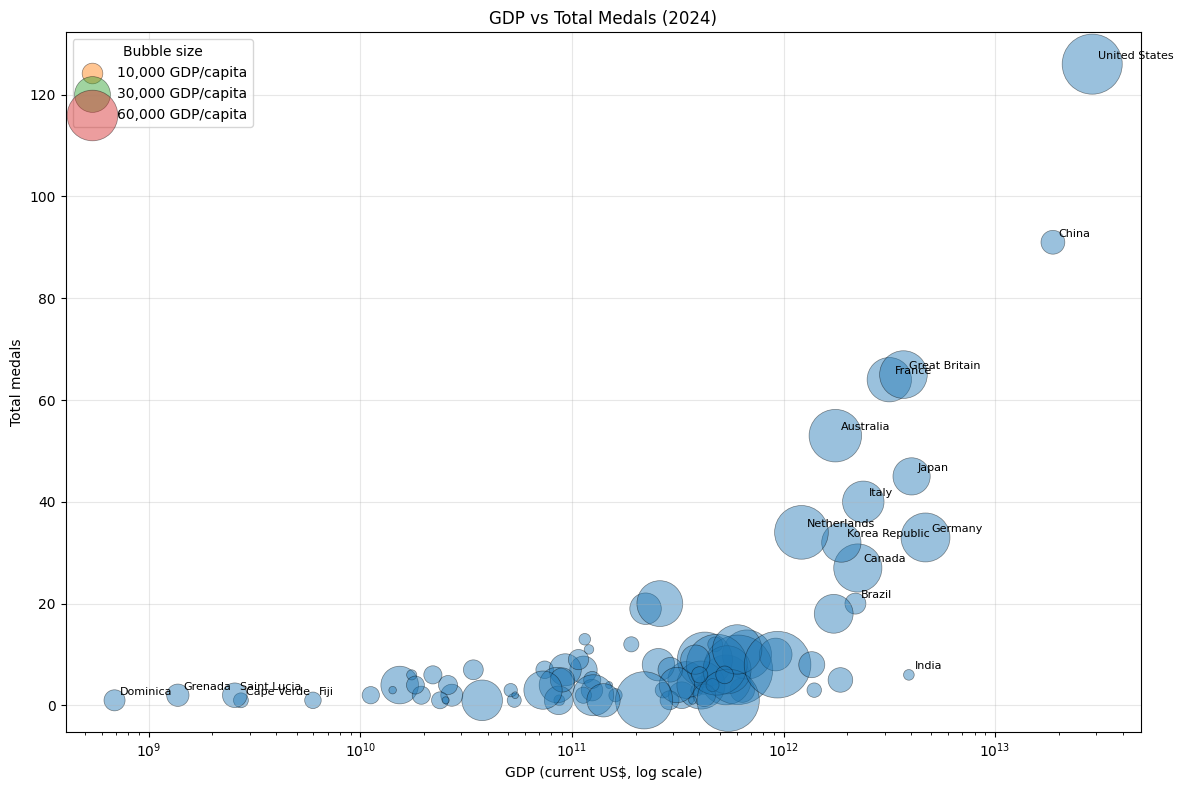

,country,year,total_medals,gdp_current_usd,gdp_per_capita
85,United States,2024,126,2.875096e+13,84534.040784
15,China,2024,91,1.874380e+13,13303.148154
32,Great Britain,2024,65,3.686033e+12,53246.367615
29,France,2024,64,3.160443e+12,46103.084086
4,Australia,2024,53,1.757022e+12,64603.985631
45,Japan,2024,45,4.027598e+12,32487.077805
43,Italy,2024,40,2.380825e+12,40385.341396
58,Netherlands,2024,34,1.214928e+12,67520.421896
31,Germany,2024,33,4.685593e+12,56103.732318
49,Korea Republic,2024,32,1.875388e+12,36238.639908


In [ ]:
gdp_per_capita_path = "../data/olympics_gdp_merged.csv"
gdp_per_capita_df = pd.read_csv(gdp_per_capita_path)

bubble_df = (
    merged_olympics_gdp.loc[merged_olympics_gdp["year"] == latest_year]
    .groupby(["country", "year"], as_index=False)
    .agg(total_medals=("medal_count", "sum"), gdp_current_usd=("gdp_current_usd", "first"))
    .merge(
        gdp_per_capita_df.groupby(["country", "year"], as_index=False).agg(
            gdp_per_capita=("gdp_per_capita", "first")
        ),
        on=["country", "year"],
        how="left",
    )
    .dropna(subset=["gdp_per_capita"])
)

bubble_sizes = bubble_df["gdp_per_capita"] / bubble_df["gdp_per_capita"].max() * 2500

plt.figure(figsize=(12, 8))
plt.scatter(
    bubble_df["gdp_current_usd"],
    bubble_df["total_medals"],
    s=bubble_sizes,
    alpha=0.45,
    edgecolors="black",
    linewidth=0.5,
)

label_df = pd.concat(
    [
        bubble_df.nlargest(10, "total_medals"),
        bubble_df.nlargest(10, "gdp_current_usd"),
        bubble_df.nsmallest(5, "gdp_current_usd"),
    ],
    ignore_index=True,
).drop_duplicates(subset=["country"])
for _, row in label_df.iterrows():
    plt.annotate(
        row["country"],
        (row["gdp_current_usd"], row["total_medals"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

size_max = bubble_df["gdp_per_capita"].max()
bubble_sizes = bubble_df["gdp_per_capita"] / size_max * 2500
# simple bubble size legend
for val in [10_000, 30_000, 60_000]:
    plt.scatter(
        [], [],
        s=val / size_max * 2500,
        alpha=0.45,
        edgecolors="black",
        linewidth=0.5,
        label=f"{val:,} GDP/capita",
    )

plt.legend(title="Bubble size", loc="upper left")
plt.xscale("log")
ax.set_xlabel('Total GDP (current US$, log scale)', color=MUTED, fontsize=10.5, labelpad=10)
ax.set_ylabel('Total medals', color=MUTED, fontsize=10.5, labelpad=10)
plt.title(f"GDP vs Total Medals ({latest_year})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

bubble_df.sort_values("total_medals", ascending=False).head(10)

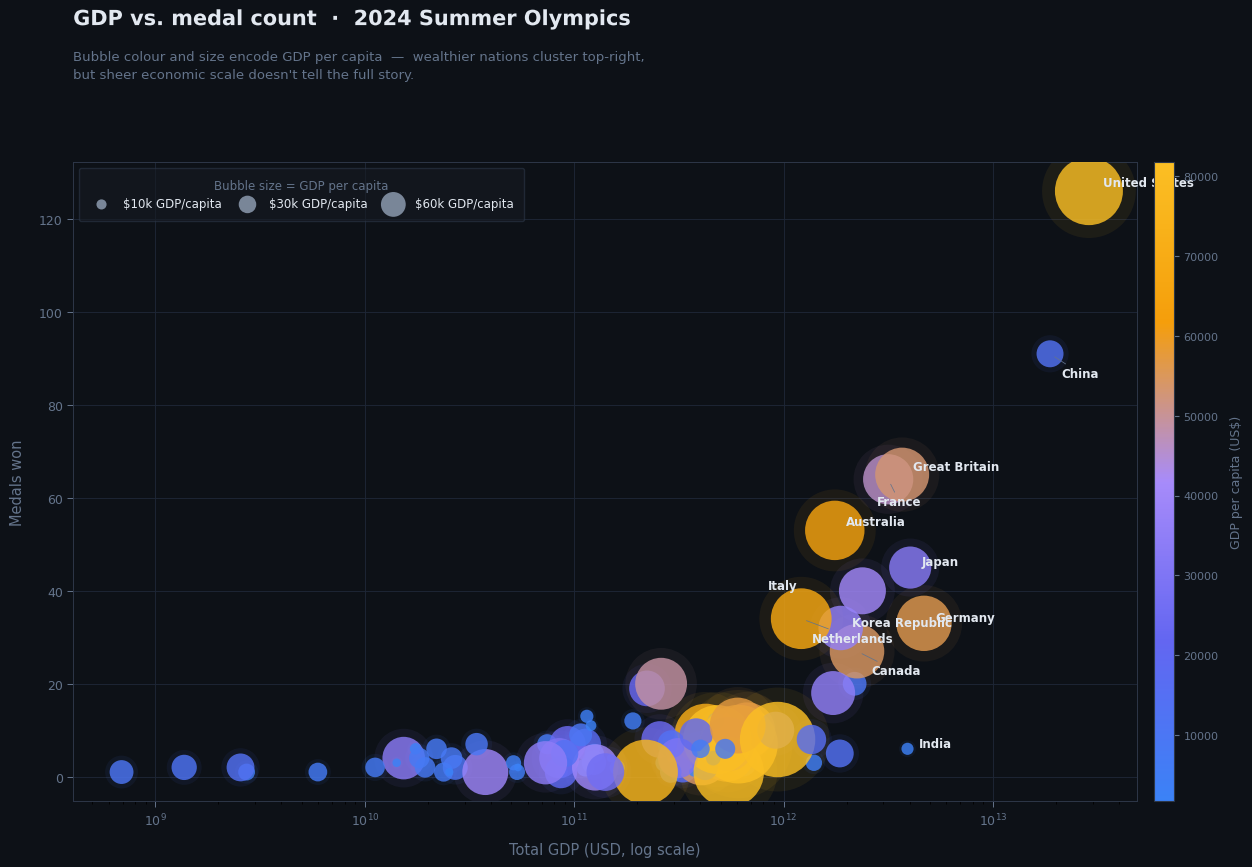

In [14]:
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable



# ── Palette ────────────────────────────────────────────────────────────────────
BG    = '#0d1117'
CARD  = '#161b22'
TEXT  = '#e2e8f0'
MUTED = '#64748b'
GRID  = '#1e2736'
DIM   = '#2d3748'

cmap = LinearSegmentedColormap.from_list(
    'gdp', ['#3b82f6', '#6366f1', '#a78bfa', '#f59e0b', '#fbbf24']
)

# ── Figure — extra top margin baked in ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG)
fig.subplots_adjust(top=0.80, bottom=0.09, left=0.08, right=0.93)
ax.set_facecolor(BG)

# ── Color & size encoding ──────────────────────────────────────────────────────
gdp_pc     = bubble_df['gdp_per_capita']
vmin, vmax = np.percentile(gdp_pc, 5), np.percentile(gdp_pc, 95)
norm       = Normalize(vmin=vmin, vmax=vmax)
colors     = cmap(norm(gdp_pc.clip(vmin, vmax)))
size_ref   = gdp_pc.max()
sizes      = gdp_pc / size_ref * 3200

# ── Subtle glow then filled bubbles ───────────────────────────────────────────
ax.scatter(bubble_df['gdp_current_usd'], bubble_df['total_medals'],
           s=sizes * 1.9, c=colors, alpha=0.07, edgecolors='none', zorder=2)
ax.scatter(bubble_df['gdp_current_usd'], bubble_df['total_medals'],
           s=sizes, c=colors, alpha=0.82, edgecolors='none', zorder=3)

# ── Grid & spines ─────────────────────────────────────────────────────────────
ax.grid(True, color=GRID, linewidth=0.65, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color(DIM)
    spine.set_linewidth(0.7)

ax.set_xscale('log')
ax.tick_params(colors=MUTED, labelsize=9, length=4, width=0.7)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_color(MUTED)

# ── Country annotations ───────────────────────────────────────────────────────
HIGHLIGHTS = set(bubble_df.nlargest(11, 'total_medals')['country']) | {'India'}
OFFSETS = {
    'United States':  ( 10,   6), 'China':          (  8, -14),
    'Great Britain':  (  8,   6), 'France':         ( -8, -16),
    'Australia':      (  8,   6), 'Japan':          (  8,   4),
    'Italy':          (-68,   4), 'Netherlands':    (  8, -14),
    'Germany':        (  8,   4), 'Canada':         ( 10, -14),
    'Korea Republic': (  8,   4), 'India':          (  8,   4),
}
for _, row in bubble_df.iterrows():
    if row['country'] not in HIGHLIGHTS:
        continue
    dx, dy = OFFSETS.get(row['country'], (8, 4))
    ax.annotate(
        row['country'],
        xy=(row['gdp_current_usd'], row['total_medals']),
        xytext=(dx, dy), textcoords='offset points',
        fontsize=8.5, color=TEXT, fontweight='600', va='center',
        arrowprops=dict(arrowstyle='-', color=MUTED, lw=0.55,
                        shrinkA=0, shrinkB=4) if abs(dy) > 8 else None,
    )

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xlabel('Total GDP (USD, log scale)', color=MUTED, fontsize=10.5, labelpad=10)
ax.set_ylabel('Medals won', color=MUTED, fontsize=10.5, labelpad=10)

# ── Title + subtitle — placed well above the axes ─────────────────────────────
fig.text(0.08, 0.97,
         f'GDP vs. medal count  ·  {latest_year} Summer Olympics',
         color=TEXT, fontsize=15, fontweight='bold', va='top',
         path_effects=[pe.withStroke(linewidth=3, foreground=BG)])
fig.text(0.08, 0.925,
         'Bubble colour and size encode GDP per capita  —  wealthier nations cluster top-right,\n'
         "but sheer economic scale doesn't tell the full story.",
         color=MUTED, fontsize=9.5, va='top', linespacing=1.55)

# ── Bubble-size legend — compact horizontal row at top of axes ────────────────
LEGEND_SCALE  = 600
legend_vals   = [10_000, 30_000, 60_000]
legend_labels = ['$10k GDP/capita', '$30k GDP/capita', '$60k GDP/capita']
legend_handles = [
    ax.scatter([], [], s=v / size_ref * LEGEND_SCALE,
               color='#94a3b8', alpha=0.80, edgecolors='none', label=lbl)
    for v, lbl in zip(legend_vals, legend_labels)
]

leg = ax.legend(
    handles=legend_handles,
    title='Bubble size = GDP per capita',
    loc='upper left',
    ncol=3,                   # ← single horizontal row
    fontsize=8.5,
    title_fontsize=8.5,
    framealpha=0.60,
    facecolor=CARD,
    edgecolor=DIM,
    labelcolor=TEXT,
    borderpad=0.9,
    handletextpad=0.8,
    columnspacing=1.2,
)
leg.get_title().set_color(MUTED)

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.015, fraction=0.022, aspect=32)
cbar.set_label('GDP per capita (US$)', color=MUTED, fontsize=9, labelpad=8)
cbar.ax.tick_params(colors=MUTED, labelsize=8)
cbar.outline.set_edgecolor(DIM)

plt.savefig('bubble_chart.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## Compute the correlation directly

The plots help visually, but it is useful to compute a simple summary number too. Here we calculate the Pearson correlation between GDP per capita and total medals for the latest year and plot the same relationship.


Pearson correlation between GDP per capita and total medals (2024): 0.355


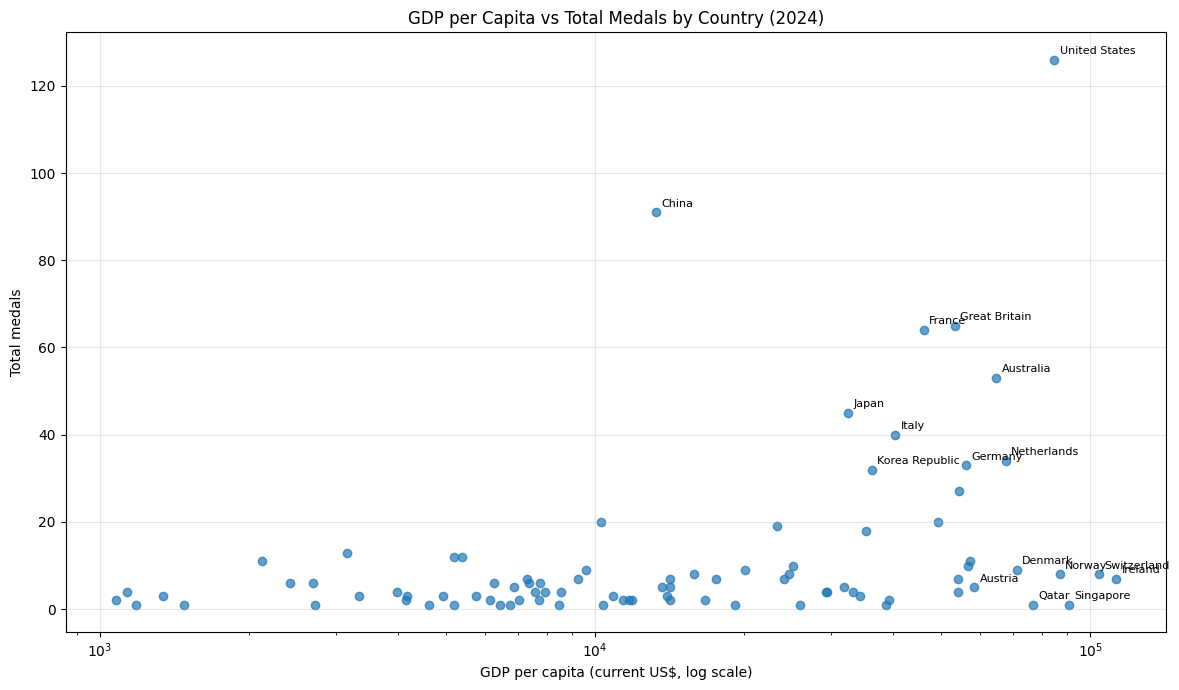

,country,gdp_per_capita,total_medals
85,United States,84534.040784,126
15,China,13303.148154,91
32,Great Britain,53246.367615,65
29,France,46103.084086,64
4,Australia,64603.985631,53
45,Japan,32487.077805,45
43,Italy,40385.341396,40
58,Netherlands,67520.421896,34
31,Germany,56103.732318,33
49,Korea Republic,36238.639908,32


In [8]:
corr_df = (
    gdp_per_capita_df.loc[gdp_per_capita_df["year"] == latest_year]
    .groupby(["country", "year"], as_index=False)
    .agg(
        total_medals=("medal_count", "sum"),
        gdp_per_capita=("gdp_per_capita", "first"),
    )
    .dropna(subset=["gdp_per_capita", "total_medals"])
)

pearson_corr = corr_df["gdp_per_capita"].corr(corr_df["total_medals"])

print(f"Pearson correlation between GDP per capita and total medals ({latest_year}): {pearson_corr:.3f}")

plt.figure(figsize=(12, 7))
plt.scatter(corr_df["gdp_per_capita"], corr_df["total_medals"], alpha=0.7)

label_corr_df = pd.concat(
    [
        corr_df.nlargest(10, "total_medals"),
        corr_df.nlargest(10, "gdp_per_capita"),
    ],
    ignore_index=True,
).drop_duplicates(subset=["country"])

for _, row in label_corr_df.iterrows():
    plt.annotate(
        row["country"],
        (row["gdp_per_capita"], row["total_medals"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

plt.xscale("log")
plt.xlabel("GDP per capita (current US$, log scale)")
plt.ylabel("Total medals")
plt.title(f"GDP per Capita vs Total Medals by Country ({latest_year})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_df[["country", "gdp_per_capita", "total_medals"]].sort_values(
    "total_medals", ascending=False
).head(10)
